In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub, os

path = kagglehub.dataset_download("prasad22/healthcare-dataset")
print(path)
print(os.listdir(path))

/home/naveedamar/.cache/kagglehub/datasets/prasad22/healthcare-dataset/versions/2
['healthcare_dataset.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "healthcare_dataset.csv"))
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [5]:
df.shape

(55500, 15)

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  str    
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  str    
 3   Blood Type          54966 non-null  str    
 4   Medical Condition   54966 non-null  str    
 5   Date of Admission   54966 non-null  str    
 6   Doctor              54966 non-null  str    
 7   Hospital            54966 non-null  str    
 8   Insurance Provider  54966 non-null  str    
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  str    
 12  Discharge Date      54966 non-null  str    
 13  Medication          54966 non-null  str    
 14  Test Results        54966 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.7 MB


In [8]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(534)

In [13]:
df = df.drop_duplicates()

In [16]:
df_numerical = df.select_dtypes(include=['int64', 'float64'])
df_categorical = df.select_dtypes(include=['object', 'category', 'str'])

In [17]:
df_categorical.describe()

,Name,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Admission Type,Discharge Date,Medication,Test Results
count,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966
unique,49992,2,8,6,1827,40341,39876,5,3,1856,5,3
top,DAvId muNoZ,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,Elective,2020-03-15,Lipitor,Abnormal
freq,3,27496,6898,9218,50,27,44,11139,18473,53,11038,18437


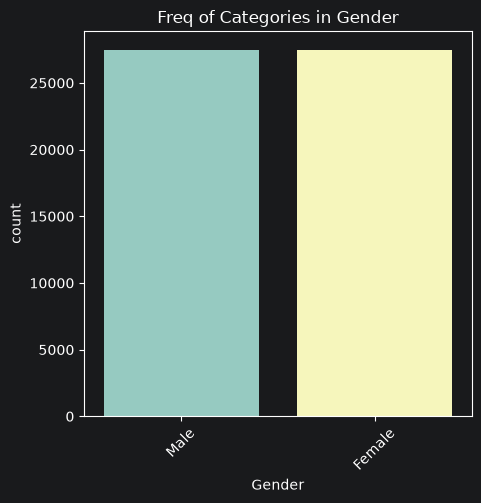

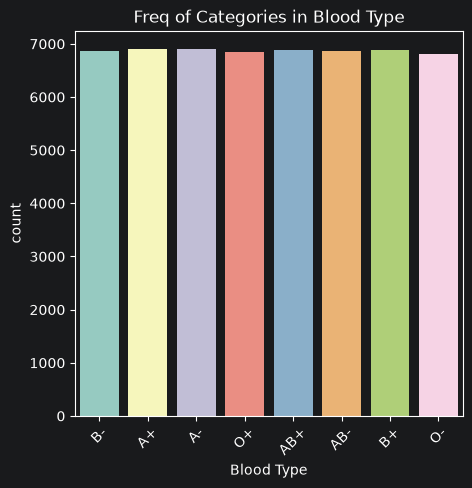

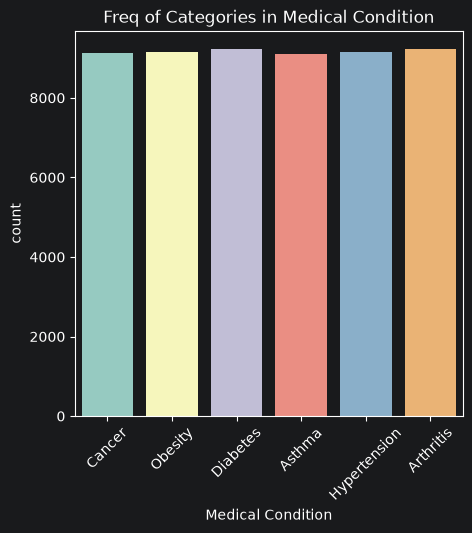

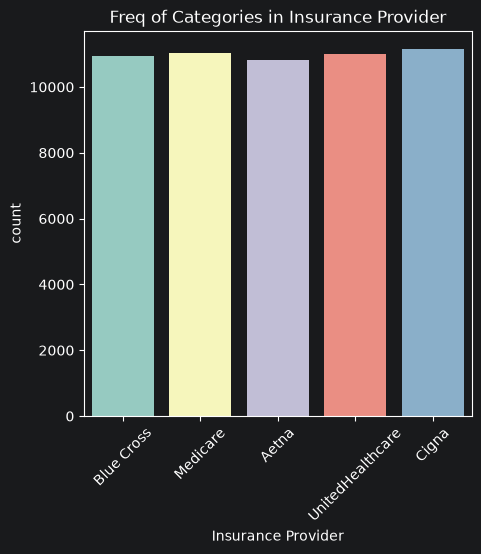

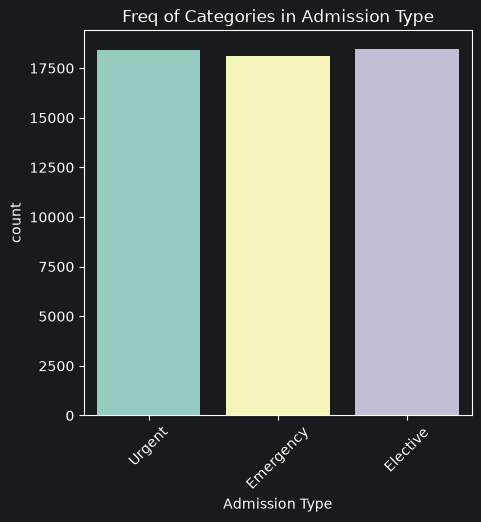

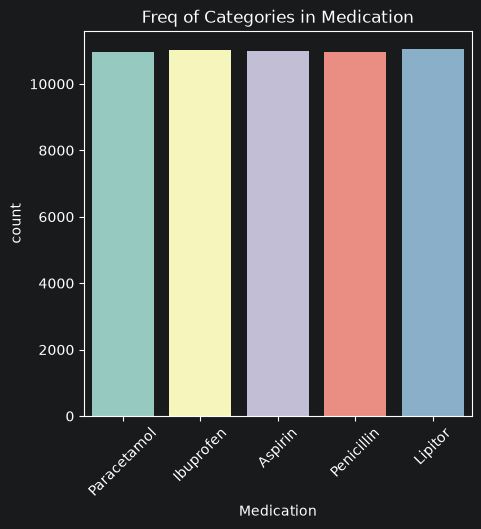

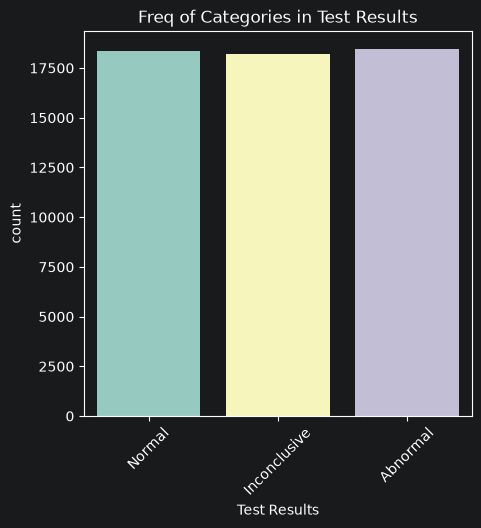

In [29]:
meaningful_cats = [col for col in df_categorical if df[col].nunique() < 15]
for category in meaningful_cats:
    plt.figure(figsize=(5, 5))
    sns.countplot(data=df, x=category, hue=category, palette="Set3", legend=False)
    plt.title(f"Freq of Categories in {category}")
    plt.xticks(rotation=45)
    plt.show()

In [39]:
df_numerical.describe()

,Age,Billing Amount,Room Number
count,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404
std,19.605661,14208.409711,115.223143
min,13.000000,-2008.492140,101.000000
25%,35.000000,13243.718641,202.000000
50%,52.000000,25542.749145,302.000000
75%,68.000000,37819.858159,401.000000
max,89.000000,52764.276736,500.000000


In [36]:
for col in df_numerical:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()

    print(f"\nColumn: {col}")
    print(f"Skewness: {skewness:.2f}")
    print(f"Kurtosis: {kurtosis:.2f}")

    if skewness > 0.5:
        print("Interpretation: Right-skewed (Positively Skewed)")
    elif skewness < -0.5:
        print("Interpretation: Left-skewed (Negatively Skewed)")
    else:
        print("Interpretation: Approximately Symmetric")

    if kurtosis > 1:
        print("Kurtosis: High - Possible Outliers")
    elif kurtosis < -1:
        print("Kurtosis: Low - Light tailed Distribution")
    else:
        print("Kurtosis: Moderate")


Column: Age
Skewness: -0.01
Kurtosis: -1.19
Interpretation: Approximately Symmetric
Kurtosis: Low - Light tailed Distribution

Column: Billing Amount
Skewness: -0.00
Kurtosis: -1.19
Interpretation: Approximately Symmetric
Kurtosis: Low - Light tailed Distribution

Column: Room Number
Skewness: -0.01
Kurtosis: -1.19
Interpretation: Approximately Symmetric
Kurtosis: Low - Light tailed Distribution


In [48]:
print(f"Column with highest skewness is {df_numerical.skew().idxmax()} with a value of {df_numerical.skew().max():.4f}")

Col with highest skewness is Billing Amount with a value of -0.0013


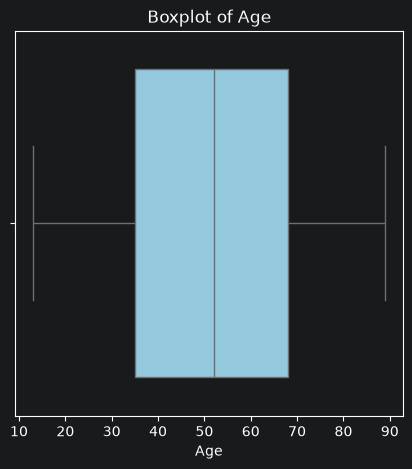

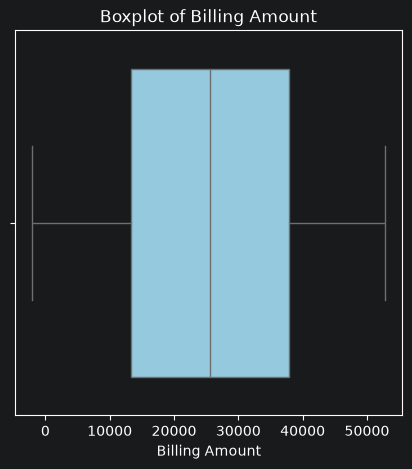

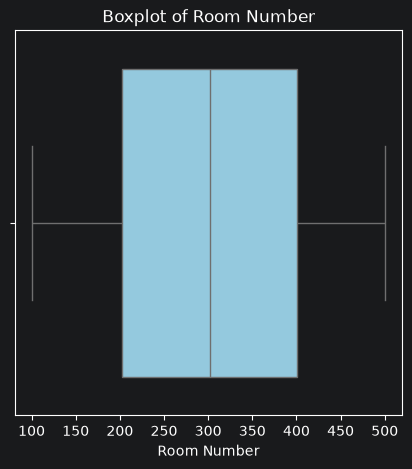

In [40]:
for col in df_numerical:
    plt.figure(figsize=(5, 5))
    sns.boxplot(data=df_numerical, x=col, color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.show()

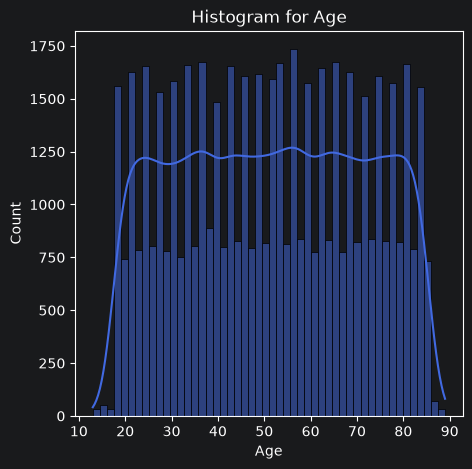

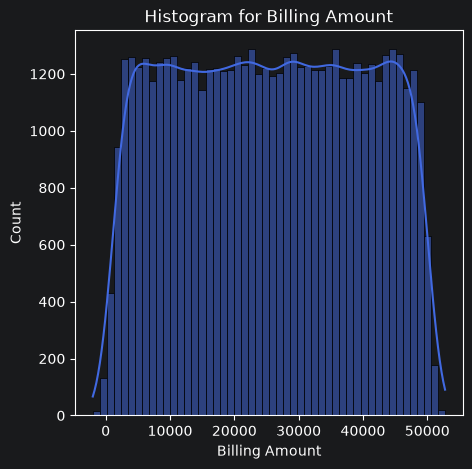

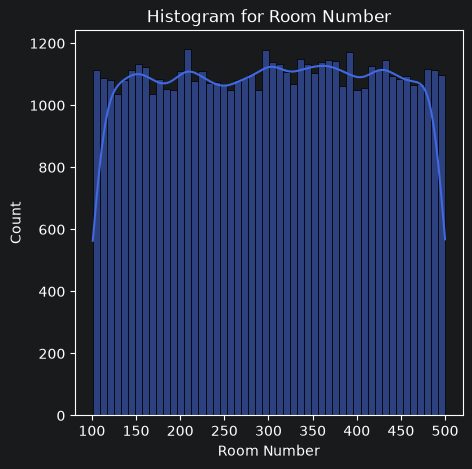

In [53]:
for col in df_numerical:
    plt.figure(figsize=(5, 5))
    sns.histplot(data=df, x=col, color='royalblue', bins=50, kde=True)
    plt.title(f"Histogram for {col}")
    plt.show()